In [1]:
# STUDENT NAME: VIKAASAN S
# STUDENT ROLL NO: 24BAD129

%pip install -q tensorflow numpy pandas matplotlib huggingface_hub datasets

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from huggingface_hub import hf_hub_download
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


c:\Users\Vikasan\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TensorFlow version: 2.21.0
NumPy version: 2.5.2


In [2]:
# LOAD TINY SHAKESPEARE FROM HUGGING FACE HUB

HF_REPO_ID = "Trelis/tiny-shakespeare"
HF_FILENAME = "input.txt"

dataset_file = hf_hub_download(
    repo_id=HF_REPO_ID,
    filename=HF_FILENAME,
    repo_type="dataset"
)

with open(dataset_file, "r", encoding="utf-8") as f:
    raw_text = f.read()

print("Tiny Shakespeare loaded successfully!")
print("Local file:", dataset_file)
print("Number of characters:", len(raw_text))
print("\nFirst 1000 characters:")
print(raw_text[:1000])


Tiny Shakespeare loaded successfully!
Local file: C:\Users\Vikasan\.cache\huggingface\hub\datasets--Trelis--tiny-shakespeare\snapshots\2225a5674b252d623cfb151ef099d179629c2f49\input.txt
Number of characters: 1115394

First 1000 characters:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the objec

c:\Users\Vikasan\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Vikasan\.cache\huggingface\hub\datasets--Trelis--tiny-shakespeare. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [3]:
# EXPLORE DATASET

print("Dataset: Tiny Shakespeare")
print("Total characters:", len(raw_text))
print("Total lines:", len(raw_text.splitlines()))

print("\nSample:")
print(raw_text[:1500])


Dataset: Tiny Shakespeare
Total characters: 1115394
Total lines: 40000

Sample:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: 

In [4]:
# TEXT PREPROCESSING

all_text = raw_text.lower()

tokens = re.findall(
    r"[a-z]+(?:'[a-z]+)?|[.,!?;:()-]",
    all_text
)

print("Total tokens:", len(tokens))
print("\nFirst 100 tokens:")
print(tokens[:100])


Total tokens: 252045

First 100 tokens:
['first', 'citizen', ':', 'before', 'we', 'proceed', 'any', 'further', ',', 'hear', 'me', 'speak', '.', 'all', ':', 'speak', ',', 'speak', '.', 'first', 'citizen', ':', 'you', 'are', 'all', 'resolved', 'rather', 'to', 'die', 'than', 'to', 'famish', '?', 'all', ':', 'resolved', '.', 'resolved', '.', 'first', 'citizen', ':', 'first', ',', 'you', 'know', 'caius', 'marcius', 'is', 'chief', 'enemy', 'to', 'the', 'people', '.', 'all', ':', 'we', "know't", ',', 'we', "know't", '.', 'first', 'citizen', ':', 'let', 'us', 'kill', 'him', ',', 'and', "we'll", 'have', 'corn', 'at', 'our', 'own', 'price', '.', "is't", 'a', 'verdict', '?', 'all', ':', 'no', 'more', 'talking', "on't", ';', 'let', 'it', 'be', 'done', ':', 'away', ',', 'away', '!']


In [5]:
# BUILD VOCABULARY

MAX_VOCAB_SIZE = 8000

tokenizer = Tokenizer(
    num_words=MAX_VOCAB_SIZE,
    oov_token="<OOV>",
    filters=""
)

tokenizer.fit_on_texts([" ".join(tokens)])

word_index = tokenizer.word_index

VOCAB_SIZE = min(
    MAX_VOCAB_SIZE,
    len(word_index) + 1
)

print("Original vocabulary size:", len(word_index))
print("Training vocabulary size:", VOCAB_SIZE)
print("\nFirst 20 words:")
print(list(word_index.items())[:20])


Original vocabulary size: 12381
Training vocabulary size: 8000

First 20 words:
[('<OOV>', 1), (',', 2), (':', 3), ('.', 4), ('the', 5), ('and', 6), ('to', 7), ('i', 8), ('of', 9), (';', 10), ('you', 11), ('my', 12), ('a', 13), ('that', 14), ('?', 15), ('in', 16), ('!', 17), ('is', 18), ('not', 19), ('for', 20)]


In [6]:
# CONVERT WORDS TO INTEGER TOKENS

integer_tokens = tokenizer.texts_to_sequences(
    [" ".join(tokens)]
)[0]

print("Integer token count:", len(integer_tokens))
print("First 30 tokens:")
print(integer_tokens[:30])


Integer token count: 252045
First 30 tokens:
[96, 276, 3, 147, 43, 977, 152, 678, 2, 135, 23, 110, 4, 41, 3, 110, 2, 110, 4, 96, 276, 3, 11, 48, 41, 1275, 355, 7, 207, 71]


In [7]:
# GENERATE INPUT SEQUENCES FOR NEXT-WORD PREDICTION

SEQUENCE_LENGTH = 10

sequences = []

for i in range(SEQUENCE_LENGTH, len(integer_tokens)):
    sequences.append(
        integer_tokens[
            i-SEQUENCE_LENGTH:i+1
        ]
    )

sequences = np.array(
    sequences,
    dtype=np.int32
)

X = sequences[:, :-1]
y = sequences[:, -1]

print("Input shape:", X.shape)
print("Target shape:", y.shape)
print("\nExample input:", X[0])
print("Example target:", y[0])


Input shape: (252035, 10)
Target shape: (252035,)

Example input: [ 96 276   3 147  43 977 152 678   2 135]
Example target: 23


In [8]:
# TRAIN / VALIDATION SPLIT

split_index = int(len(X) * 0.90)

X_train = X[:split_index]
y_train = y[:split_index]

X_val = X[split_index:]
y_val = y[split_index:]

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))


Training samples: 226831
Validation samples: 25204


In [9]:
# BUILD RNN MODEL

EMBEDDING_DIM = 128
RNN_UNITS = 128

model = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),
    SimpleRNN(RNN_UNITS),
    Dense(
        VOCAB_SIZE,
        activation="softmax"
    )
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
# TRAIN RNN

EPOCHS = 10
BATCH_SIZE = 128

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)


Epoch 1/10
1773/1773 ━━━━━━━━━━━━━━━━━━━━ 83s 45ms/step - accuracy: 0.1233 - loss: 5.7177 - val_accuracy: 0.1468 - val_loss: 5.4658
Epoch 2/10
1773/1773 ━━━━━━━━━━━━━━━━━━━━ 84s 47ms/step - accuracy: 0.1600 - loss: 5.0888 - val_accuracy: 0.1560 - val_loss: 5.3464
Epoch 3/10
1773/1773 ━━━━━━━━━━━━━━━━━━━━ 127s 39ms/step - accuracy: 0.1756 - loss: 4.8313 - val_accuracy: 0.1608 - val_loss: 5.3506
Epoch 4/10
1773/1773 ━━━━━━━━━━━━━━━━━━━━ 72s 40ms/step - accuracy: 0.1878 - loss: 4.6348 - val_accuracy: 0.1595 - val_loss: 5.3568
Epoch 5/10
1773/1773 ━━━━━━━━━━━━━━━━━━━━ 71s 40ms/step - accuracy: 0.1981 - loss: 4.4662 - val_accuracy: 0.1597 - val_loss: 5.4079
Epoch 6/10
1773/1773 ━━━━━━━━━━━━━━━━━━━━ 65s 36ms/step - accuracy: 0.2081 - loss: 4.3115 - val_accuracy: 0.1591 - val_loss: 5.4724
Epoch 7/10
1773/1773 ━━━━━━━━━━━━━━━━━━━━ 64s 36ms/step - accuracy: 0.2192 - loss: 4.1670 - val_accuracy: 0.1520 - val_loss: 5.5508
Epoch 8/10
1773/1773 ━━━━━━━━━━━━━━━━━━━━ 63s 36ms/step - accuracy: 0.2303 

In [11]:
# FINAL PERFORMANCE

print(
    f"Training Accuracy   : {history.history['accuracy'][-1]:.4f}"
)
print(
    f"Validation Accuracy : {history.history['val_accuracy'][-1]:.4f}"
)
print(
    f"Training Loss       : {history.history['loss'][-1]:.4f}"
)
print(
    f"Validation Loss     : {history.history['val_loss'][-1]:.4f}"
)


Training Accuracy   : 0.2589
Validation Accuracy : 0.1492
Training Loss       : 3.7691
Validation Loss     : 5.7612


In [12]:
# PERFORMANCE TABLE

results_df = pd.DataFrame({
    "Epoch": range(1, len(history.history["accuracy"]) + 1),
    "Training Accuracy": history.history["accuracy"],
    "Validation Accuracy": history.history["val_accuracy"],
    "Training Loss": history.history["loss"],
    "Validation Loss": history.history["val_loss"]
})

display(results_df)


,Epoch,Training Accuracy,Validation Accuracy,Training Loss,Validation Loss
0,1,0.123277,0.146762,5.717699,5.465820
1,2,0.159969,0.155967,5.088834,5.346353
2,3,0.175558,0.160808,4.831277,5.350631
3,4,0.187796,0.159498,4.634812,5.356814
4,5,0.198103,0.159737,4.466230,5.407859
5,6,0.208058,0.159141,4.311480,5.472378
6,7,0.219216,0.152000,4.166961,5.550833
7,8,0.230348,0.153864,4.028265,5.628455
8,9,0.244089,0.151008,3.895397,5.697773
9,10,0.258880,0.149222,3.769127,5.761175


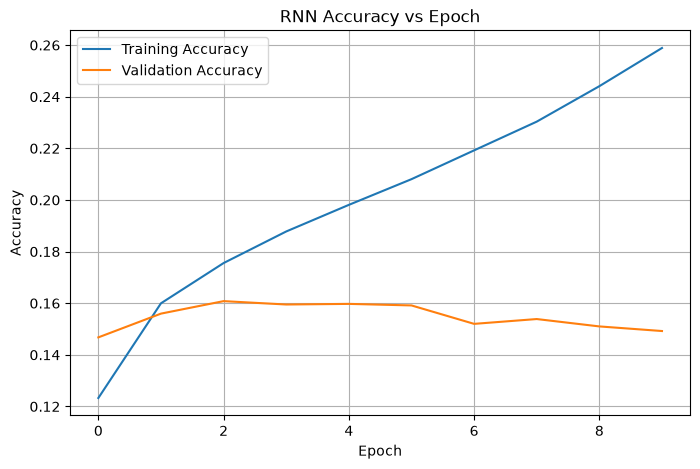

In [13]:
# ACCURACY VS EPOCH

plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("RNN Accuracy vs Epoch")
plt.legend()
plt.grid(True)
plt.show()


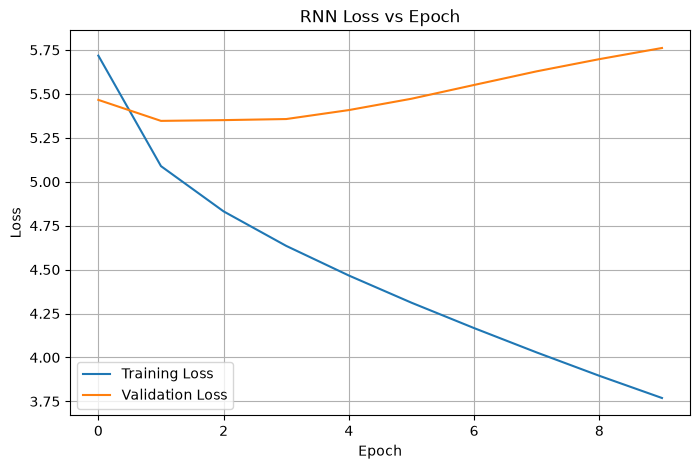

In [14]:
# LOSS VS EPOCH

plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RNN Loss vs Epoch")
plt.legend()
plt.grid(True)
plt.show()


In [15]:
# VALIDATION EVALUATION

val_loss, val_accuracy = model.evaluate(
    X_val,
    y_val,
    batch_size=BATCH_SIZE,
    verbose=1
)

print(f"Validation Loss     : {val_loss:.4f}")
print(f"Validation Accuracy : {val_accuracy:.4f}")


197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.1492 - loss: 5.7612
Validation Loss     : 5.7612
Validation Accuracy : 0.1492


In [16]:
# REVERSE VOCABULARY

index_to_word = {
    index: word
    for word, index in tokenizer.word_index.items()
    if index < VOCAB_SIZE
}

print("Reverse vocabulary entries:", len(index_to_word))


Reverse vocabulary entries: 7999


In [17]:
# PREDICT NEXT WORD

def predict_next_word(seed_text, temperature=0.7):
    words = re.findall(
        r"[a-z]+(?:'[a-z]+)?|[.,!?;:()-]",
        seed_text.lower()
    )

    sequence = tokenizer.texts_to_sequences(
        [" ".join(words)]
    )[0]

    sequence = sequence[-SEQUENCE_LENGTH:]

    sequence = pad_sequences(
        [sequence],
        maxlen=SEQUENCE_LENGTH,
        padding="pre"
    )

    predictions = model.predict(
        sequence,
        verbose=0
    )[0]

    predictions = np.asarray(
        predictions,
        dtype=np.float64
    )

    predictions = np.log(
        predictions + 1e-8
    ) / temperature

    probabilities = tf.nn.softmax(
        predictions
    ).numpy()

    next_index = np.random.choice(
        len(probabilities),
        p=probabilities
    )

    return index_to_word.get(
        next_index,
        "<OOV>"
    )


In [18]:
# GENERATE TEXT

def generate_text(
    seed_text,
    num_words=30,
    temperature=0.7
):
    generated = seed_text.lower()

    for _ in range(num_words):
        next_word = predict_next_word(
            generated,
            temperature
        )
        generated += " " + next_word

    return generated

seed = "to be or not"

print("Seed:")
print(seed)

print("\nGenerated Text:")
print(
    generate_text(
        seed,
        num_words=30,
        temperature=0.7
    )
)


Seed:
to be or not

Generated Text:
to be or not . i am not to - day , what ? queen margaret : o , be , england's king , who calls upon me ? now my worships <OOV> <OOV>


In [19]:
# MULTIPLE SEED INPUTS

seed_inputs = [
    "to be or not",
    "the king",
    "my lord",
    "what is",
    "love is"
]

for seed in seed_inputs:
    print("=" * 70)
    print("SEED:", seed)
    print("GENERATED:")
    print(
        generate_text(
            seed,
            num_words=30,
            temperature=0.7
        )
    )
    print()


SEED: to be or not
GENERATED:
to be or not . leontes : withdraw my own friends ! king henry vi henry bolingbroke : i have a little woman , i would have done ; and , but i say

SEED: the king
GENERATED:
the king . prince : how plainly night , i have you well ; if i were , as i guess , my lord , i have , by her of <OOV>

SEED: my lord
GENERATED:
my lord forgiveness : the duke of friends , and good george ; for i will do't ; i would do much . king edward iv : what , ho ! lady

SEED: what is
GENERATED:
what is not . second murderer : it is it is so . look you , sir , it is so <OOV> . duke vincentio : her uncle , and i can

SEED: love is
GENERATED:
love is butcher'd . lady anne : now , jack , i would say tis well . escalus : i beseech you , if you please your honour : he shall come



In [20]:
# TEMPERATURE COMPARISON

seed = "to be or not"

for temperature in [0.5, 0.8, 1.0]:
    print("=" * 70)
    print("Temperature:", temperature)
    print(
        generate_text(
            seed,
            num_words=25,
            temperature=temperature
        )
    )


Temperature: 0.5
to be or not . they are past , but to remit the brats of his son . the king richard iii : o , then , i will
Temperature: 0.8
to be or not ; if you perceive your grace nor pardon me , and do not come in your heart to die . friar laurence : he gallops
Temperature: 1.0
to be or not so tedious late joy : they say you have , my noble fellow is a measure ; and he should purchase with us : the
